# `DemandProfile` class

`DemandProfile` instances compute, store, and provide the thermal demand  of a heating system during a whole operation year.  

They allow the user to introduce daily demand profiles with time resolutions as small as 30 minutes.  

They also take into account the dependence of the demanded power on the ambient temperature, also being capable of determining that degree of dependence based on the monthly heat demand provided by the user.

In [1]:
# Import DemandProfile and other modules needed
# If the two last code lines are activated, the plots will be rendered in separate windows

from sercpy.demand_profile import DemandProfile
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'qt')

## Defining the `DemandProfile` instance: A first approach

#### Introducing a daily demand profile

The most precise way of constructing a `DemandProfile` object is by first introducing a daily demand profile, which defines how the heat demand is distributed during a 24-hour day.  

The most standard way of defining a daily demand profile is by providing a `list` of up to 48 values. These 48 values represent a 24-hour day with 30-minute resolution. This `list` can also have less values. In this case, the number of values must be a divisor of 24 (or 24 itself). For example, an 8-value `list` defines a daily demand profile with each value encompassing 3 hours of the day.

To make this process easier, the class includes a small app to define the profiles in a more graphical way.

In [2]:
# Open app to define profiles. The lists are printed in a text box and must be copied and pasted to the code.
DemandProfile.open_profiles_app()

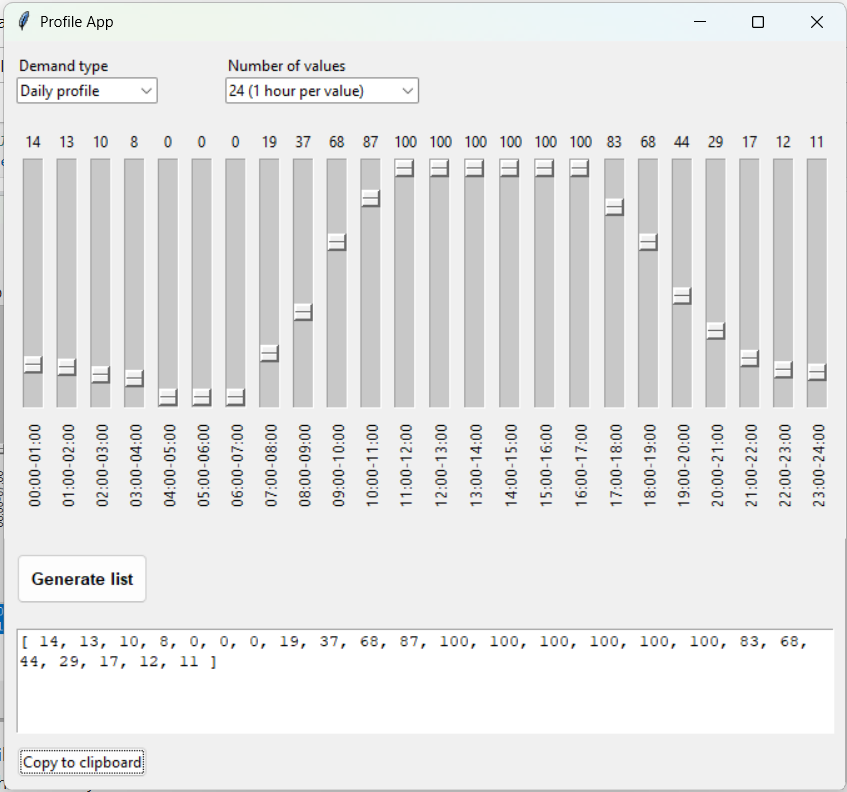  

The following profile has been copied and pasted from the app, as shown in the image. The values do not have any energy units; they only define how heat demand gets distributed throughout the day; hence, what matters their values relative to each other.

In [3]:
# The following profile has been copied and pasted from the app
daily_demand_profile = [ 14, 13, 10, 8, 0, 0, 0, 19, 37, 68, 87, 100, 100, 100, 100, 100, 100, 83, 68, 44, 29, 17, 12, 11 ]

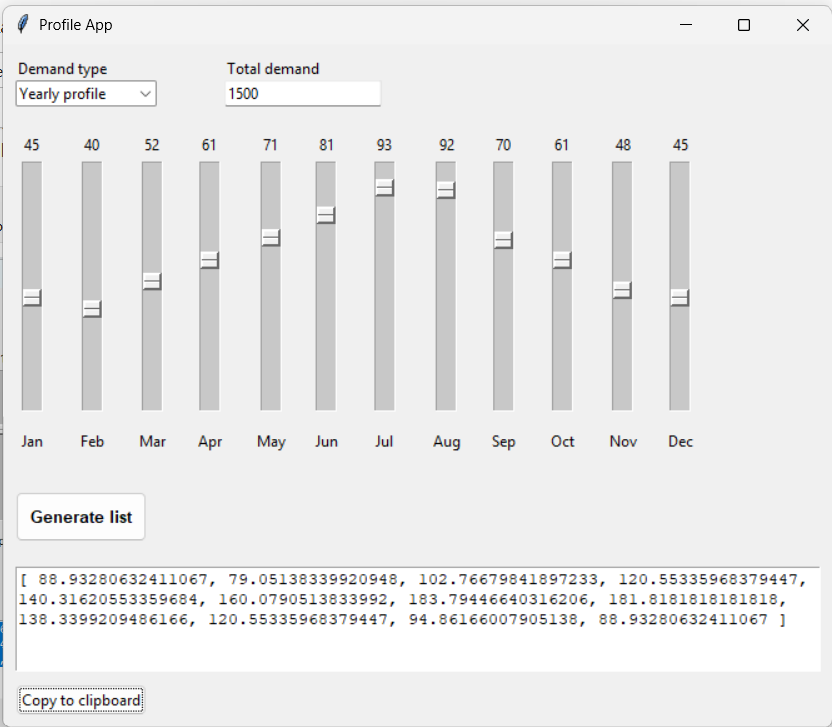  

The app can also be used to generate monthly heat demand profiles, as the image above shows. In this case, the total amount of energy does matter. Hence, a total value must be provided, and it will be distributed proportionally to the value corresponding to each month.

In [4]:
# Define the list of monthly heat demands, along with the heat demand units
monthly_heat_demand = [ 
    88.93280632411067, 79.05138339920948, 102.76679841897233,
    120.55335968379447, 140.31620553359684, 160.0790513833992,
    183.79446640316206, 181.8181818181818, 138.3399209486166,
    120.55335968379447, 94.86166007905138, 88.93280632411067 ]
heat_demand_units = "MWh"

#### Dependence of thermal demand on ambient temperature

Depending on the type of thermal load, the energy demand could be heavily dependent on ambient temperature. An obvious example is room heating.

The paper presented by Jesper et al. [1] proposes four discrete levels of dependence. The following image shows how the same yearly demand gets distributed among the 12 months of the year with each dependence level. The temperature data used to predict the distributions corresponds to a typical meteorological year (TMY) file provided by the "Explorador Solar" of the Ministry of Energy of Chile [2]. The location used to generate the TMY file is the "San Joaquin" Campus of the Pontifical Catholic University of Chile. 

<div align="center">
    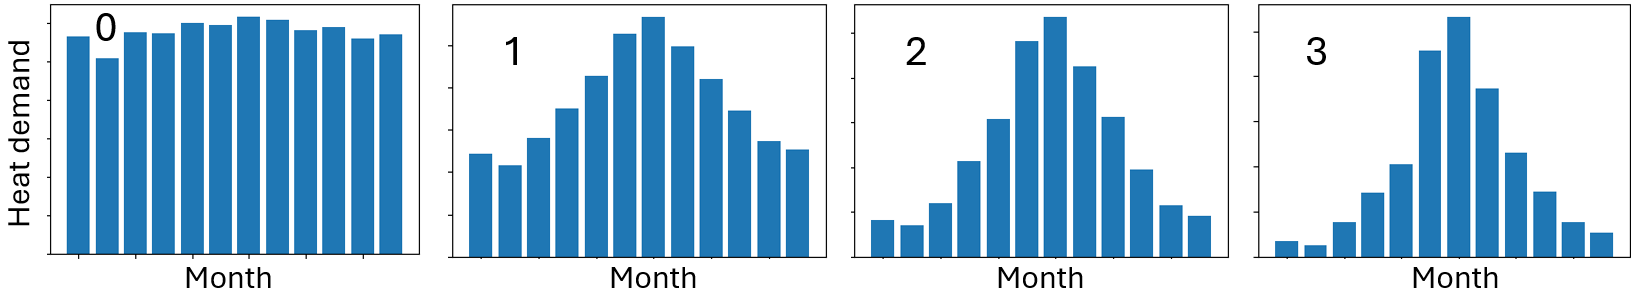 <br>
    Monthly demand profiles assuming four different levels of dependence of the thermal demand on ambient temperature
</div>

<br>

Sercpy has expanded the method proposed by Jesper et al. [1] to consider a continuous spectrum of dependence levels instead of the four discrete levels originally proposed. Moreover, the platform includes an algorithm to determine the dependence level based on the monthly heat demand provided by the user.

[1]   Mateo Jesper, Felix Pag, Klaus Vajen, Ulrike Jordan. Annual Industrial and Commercial Heat Load Profiles: Modeling Based on k-Means Clustering  and Regression Analysis. Energy Conversion and Management: X, Volume 10, June 2021, 100085

[2]   Explorador Solar, Ministry of Energy of Chile. URL: https://solar.minenergia.cl/inicio

#### Ambient temperature profile

In order to determine the level of dependence of the thermal demand on the ambient temperature, an ambient temperature profile encompassing a whole year must be provided.  

This profile must have at least a daily resolution; i.e., 365 values, where each value represents the average temperature of each day. It is also allowed to provide profiles with higher resolution, but the number of elements in the profile must be a multiple of 365, and it always has to represent an entire year of data.  

Ideally, the data provided should correspond to the same year in which the thermal demand was registered. In this example, the same TMY data file mentioned above will be used.

In [5]:
# Import the TMY data file and convert the ambient temperature column to a list

tmy_data = pd.read_csv( "TMY_San_Joaquin.csv" )
Tamb_profile = tmy_data[ "temp" ].values.astype(float).tolist()

In [6]:
# After specifying the heated fluid,
# the temperature of the fluid that enters the heating system,
# and the setpoint temperture (both temperatures in °C),
# there is enough data to define a DemandProfile object

fluid = 'water'
T_in = 40
T_set = 60

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

Since an ambient temperature profile was provided to the `DemandProfile` object when it was initialized, a level of temperature dependence was automatically determined. It is possible to get that value by using the method `demand_1.get_attribute()`. In this case, the name of the attribute is `"Tamb_dependence"`:

In [7]:
print( demand_1.get_attribute( "Tamb_dependence" ) )

0.878320312500001


#### Specifying the monthly production

The method just shown to determine the dependence of thermal demand on ambient temperature implicitly assumes that the only cause for having different demand levels throughout the year is changes in ambient temperature.

Nevertheless, it must me considered that different demand levels also could be casued by changes in production levels. To take this into account, the user can provide the optional parameter `monthly_production`, which also consists of a list of 12 values. The production units do not actually matter; what matters is how the numbers change from one month to another.

The production profile shown in the image below implies that some (although not all) of the variance in demand is due to changes in production levels; therefore, the dependence coefficient should be lower this time.

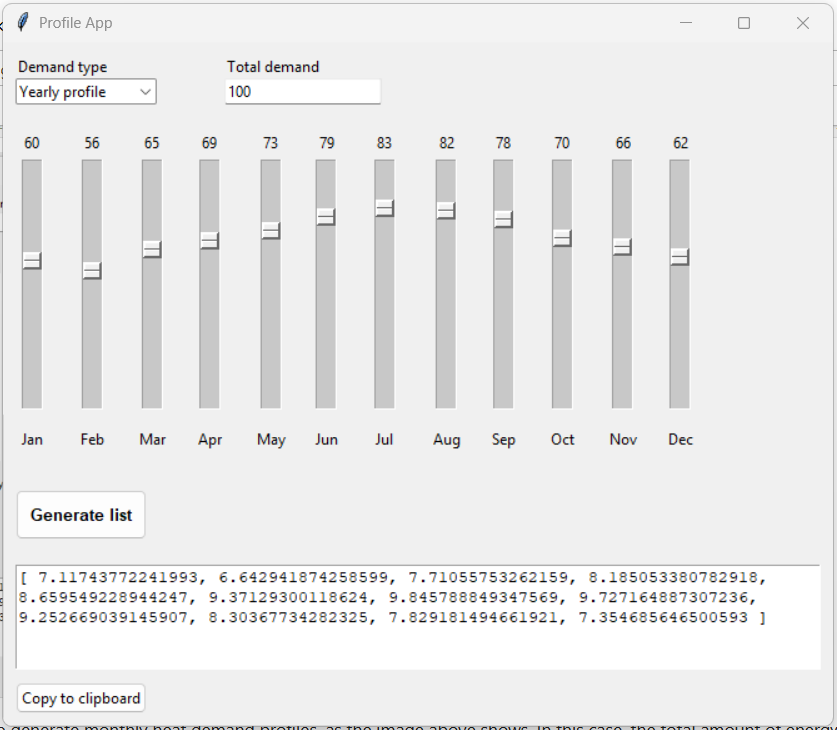

In [8]:
# Define a monthly production profile
monthly_production = [
    7.11743772241993, 6.642941874258599, 7.71055753262159,
    8.185053380782918, 8.659549228944247, 9.37129300118624,
    9.845788849347569, 9.727164887307236, 9.252669039145907,
    8.30367734282325, 7.829181494661921, 7.354685646500593 ]

In [9]:
# Define a new DemandProfile instance including the monthly production
demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    monthly_heat_demand = monthly_heat_demand,
    monthly_production = monthly_production,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

In [10]:
# The dependence of demand on ambient temperature is indeed lower in this case
print( demand_1.get_attribute( "Tamb_dependence" ) )

0.5764648437500002


### Plotting the weekly profile of a `DemandProfile` instance 

The attribute called `"weekly_demand_profile"` is a `list` of values that defines how heat demand gets distributed during an entire week. Since in this case a single daily profile was provided, all days are equal.  

Notice that this profile is only a baseline to construct the yearly profile. In the actual yearly profile, the demand will vary from day to day because of other factors such as the ambient temperature.

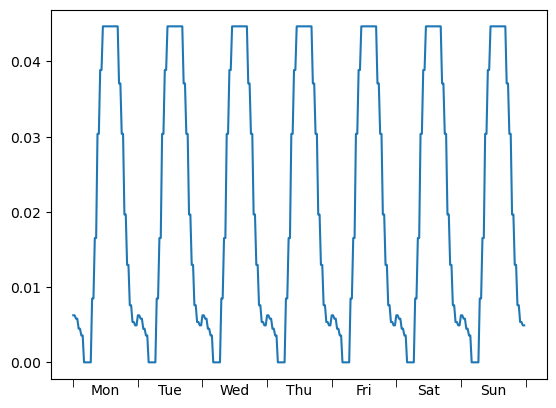

In [11]:
# Function to plot the weekly demand profile of a DemandProfile instance.
def plot_weekly_profile( demand_profile_instance ):
    # Get the attribute 'weekly_profile' from the object
    weekly_profile = demand_profile_instance.get_attribute( "weekly_demand_profile" )
    
    # Plot the profile
    fig, ax = plt.subplots()
    plt.plot( weekly_profile )
    
    # Show week day names in the horizontal axis
    day_names = [ 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun' ]
    n_days = 7
    len_day = len( weekly_profile )//n_days
    edges = len_day * np.arange(n_days + 1) # Where to draw lines
    centers = len_day * (np.arange(n_days) + 0.5) # Where to write day names
    
    # Major ticks: labels only, no visible tick marks
    ax.set_xticks(centers)
    ax.set_xticklabels(day_names)
    ax.tick_params(axis='x', which='major', length=0)
    
    # Minor ticks: the dividing lines at section boundaries, no labels
    ax.set_xticks(edges, minor=True)
    ax.tick_params(axis='x', which='minor', length=6)
    
    plt.show()

# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

## Alternative methods for defining the demand profile

### Scaling the profile for weekend days

In order to set different demands for the weekends, there is the possibility of specifying the parameters `daily_demand_ratio_saturday`and `daily_demand_ratio_sunday`.

These parameters are scalar values that define the ratio between the demand on the corresponding day (saturday or sunday) and a "normal" weekday.

**Regarding these two parameters, there are two things to keep in mind:**

- If only the parameter `daily_demand_ratio_saturday` is specified, sunday is assumed to have zero demand.
- If only the parameter `daily_demand_ratio_sunday` is specified, saturday is assumed to be a normal day.

In [12]:
# Setting a different demand only for saturday
# Sunday is thus assumed to have no demand

daily_demand_ratio_saturday = 0.6

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

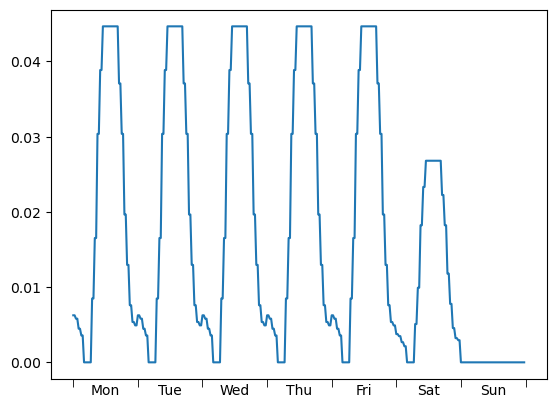

In [13]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

In [14]:
# Setting a different demand only for sunday
# Saturday is thus assumed to be a normal day

daily_demand_ratio_sunday = 0.3

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_ratio_sunday = daily_demand_ratio_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

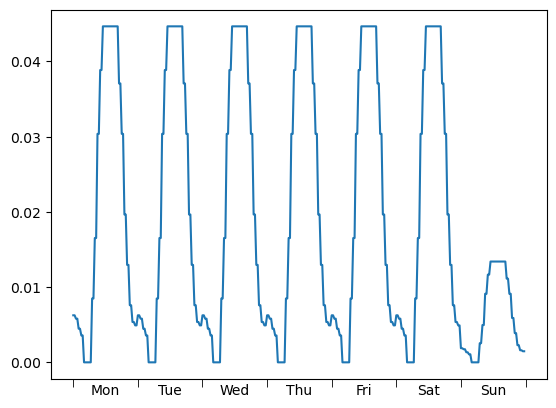

In [15]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

In [16]:
# Setting different values for both weekend days

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    daily_demand_ratio_sunday = daily_demand_ratio_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

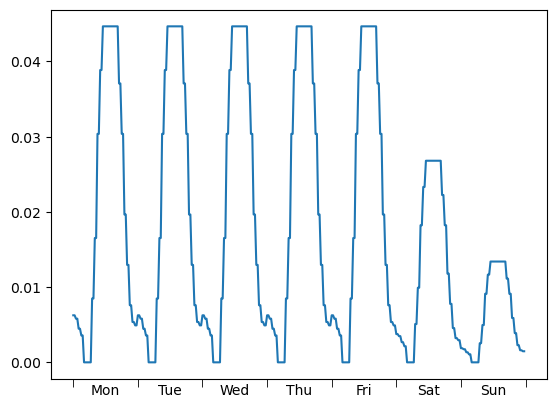

In [17]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### Setting different profiles for weekend days

There is also the possibility of setting completely different daily profiles for saturdays and sundays. This is done with the parameters `daily_demand_profile_saturday` and `daily_demand_profile_sunday`, which, just like the parameter `daily_demand_profile`, are lists of values representing a 24-hour day.

**The assumption is the same as with the scalar parameters `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday`:**

- If only the parameter `daily_demand_profile_saturday` is specified, sunday is assumed to have zero demand.
- If only the parameter `daily_demand_profile_sunday` is specified, saturday is assumed to have the same demand profile as the week days.

**Another feature to take into account is as follows:**

The philosophy of daily demand profiles is to make it simple for the user to introduce an approximate "shape" of the demand distribution in time throughout a 24-hour period. In order to keep this simplicity, the values introduced in different daily profiles are not assumed to have comparable scales. For this reason, it is ***necessary*** to also specify scalar values to set the scale of the demand on weekend days, such as the parameters `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday` explained above. See the following image and the explanation below for more clarification.  

<br>

<div align="center">
    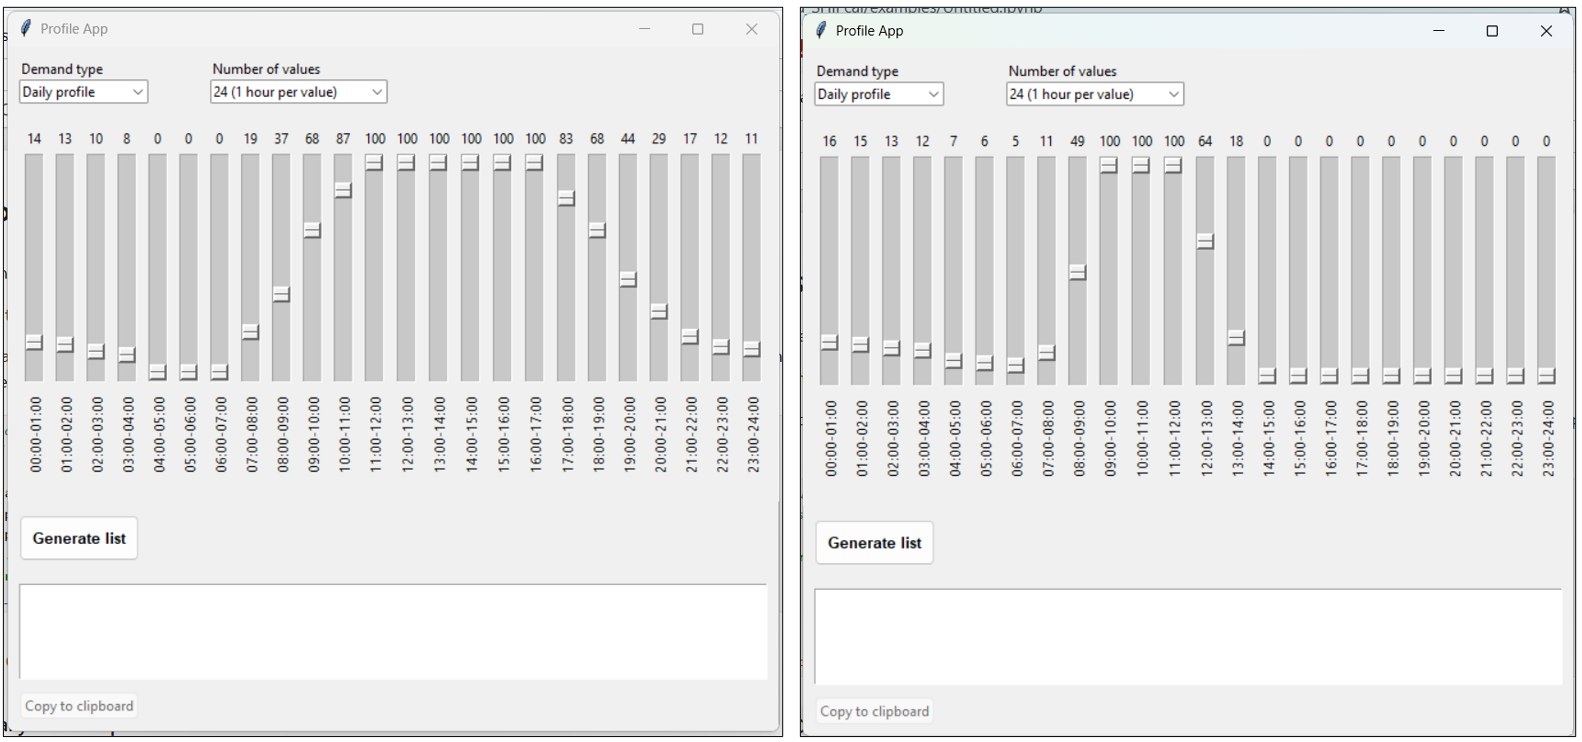 <br>
    Demand profile for week days (left) and daily profile for saturdays (right)
</div>

<br>

The image shows two different demand profiles. The one on the left is assumed to be a "normal" day (i.e., week day) and the one on the right is assumed to be the daily profile for saturday.

In this example, it is possible to infer that the thermal load only operates in the morning on saturdays. However, the platform does not make any assumptions regarding how much energy the thermal load demands on saturdays (the peak demand could be the same as on week days, but this is not assumed by default).

Therefore, special daily profiles for weekend days must be specified along with scalar values defining the scale of the demand on those days.

In [18]:
# Specify the daily profile for saturday
daily_demand_profile_saturday = [ 16, 15, 13, 12, 7, 6, 5, 11, 49, 100, 100, 100, 64, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0 ]

# Just for clarity, the parameter 'daily_demand_ratio_saturday' is defined again
daily_demand_ratio_saturday = 0.6

# Define the instance of 'DemandProfile' again

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_profile_saturday = daily_demand_profile_saturday,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

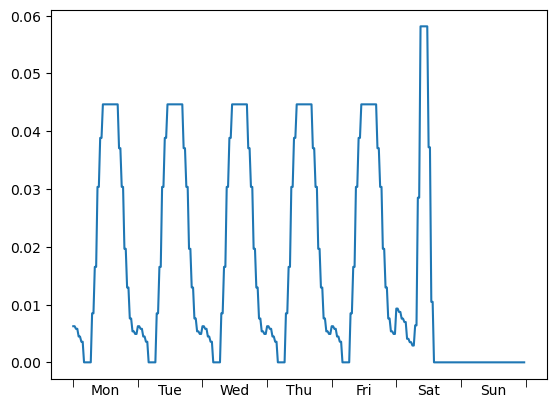

In [19]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### Setting the peak demand instead of the daily demand

After re-plotting the weekly demand profile for the `DemandProfile` instance just created, the user may have found curious that the demand seems to be higher on saturdays despite having set the value of `daily_demand_ratio_saturday` at `0.6`.

This is because the argument `daily_demand_ratio_saturday` actually sets the ratio between the ***total*** daily demand on saturdays and the ***total*** daily demand on week days. Since the thermal load operates less time on saturdays, it has to reach a higher peak to achieve the demand ratio specified.

In order to set the peak demand for weekend days instead of the total daily demand, the user can specify the arguments `peak_demand_ratio_saturday` and `peak_demand_ratio_sunday`.

If not special profiles are provided for weekend days, then the arguments `peak_demand_ratio_saturday` and `peak_demand_ratio_sunday` have the same effect as `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday`.

In [20]:
# Set the peak demand for saturday instead of the total daily demand

peak_demand_ratio_saturday = 0.6

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_profile_saturday = daily_demand_profile_saturday,
    peak_demand_ratio_saturday = peak_demand_ratio_saturday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

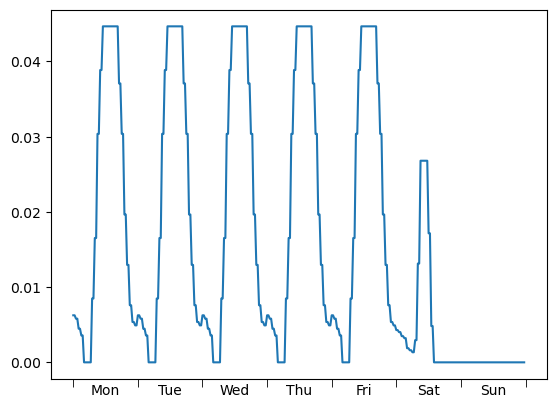

In [21]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### Specifying a different profile for each day

Until now, the `DemandProfile` instance has been constructed using a "baseline" daily demand profile for week days, and optionally adding special demand profiles for weekend days.

If the user wants to specify different daily profiles for each day of the week, there is the argument `daily_demand_profiles` (notice the difference with `daily_demand_profile`).

The argument `daily_demand_profiles` is a list of seven lists, where each list represents the profile of one day, starting on monday.

Following the assumption that profiles of different days are not comparable as being on the same scale, the argument `daily_demand_profiles` ***always*** has to be specified along with another argument called `weekly_demand_factors`. This argument is a list of seven values, where each value represents the relative daily demand of each day. **Important:** These values are interpreted as representing the scale of the ***total*** demand of the corresponding day; not the peak demand.

The app to generate profiles can also be used to generate the parameter `weekly_demand_factors`, as the image below shows.  

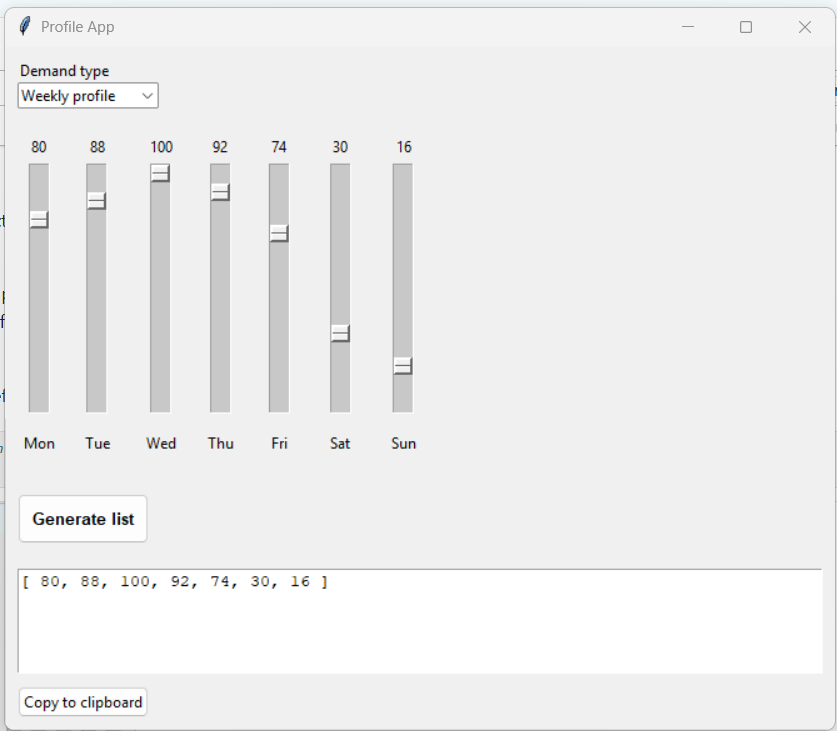  

In [22]:
# Define the parameter 'daily_demand_profiles'

daily_demand_profiles = [
    [ 14, 33, 67, 80, 89, 67, 60, 11 ],
    [ 49, 55, 67, 70, 74, 67, 60, 56 ],
    [ 23, 48, 58, 80, 52, 26, 17, 23 ],
    [ 70, 30, 33, 33, 38, 60, 70, 75 ],
    [ 0, 0, 67, 76, 77, 70, 0, 0 ],
    [ 19, 19, 67, 76, 77, 89, 38, 19 ],
    [ 19, 51, 67, 76, 77, 62, 38, 19 ],
]

# Define the parameter 'weekly_demand_factors'
weekly_demand_factors = [ 80, 88, 100, 92, 74, 30, 16 ]

demand_1 = DemandProfile(

    daily_demand_profiles = daily_demand_profiles,
    weekly_demand_factors = weekly_demand_factors,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

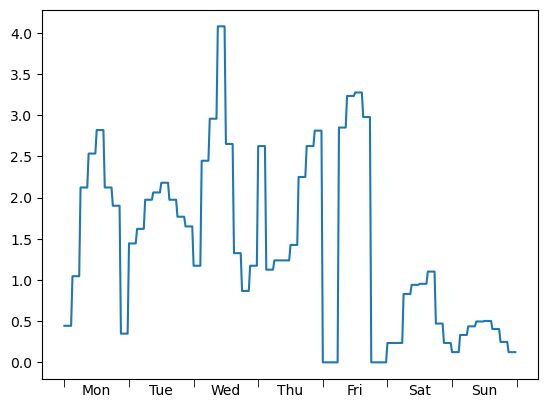

In [23]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

The argument `weekly_demand_factors` can also be used when only one daily profile is provided through the argument `daily_demand_profile`. In this way, the "shape" of the demand profile is the same every day, but it gets scaled every day by a different factor given by the list `weekly_demand_factors`.

In [24]:
# Using a single daily demand profile and scaling it every day by a different factor by using the argument 'weekly_demand_factors'

demand_1 = DemandProfile(
    
    daily_demand_profile = daily_demand_profile,
    weekly_demand_factors = weekly_demand_factors,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

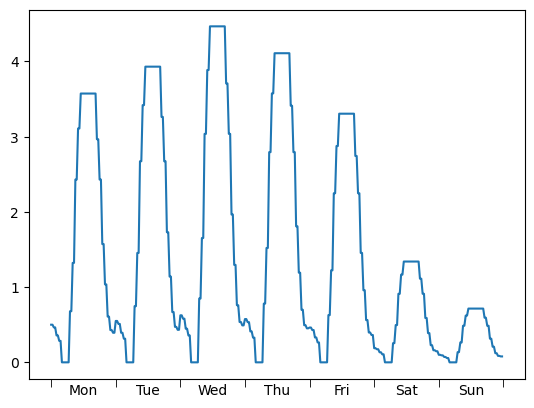

In [25]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### Specifying all days of the week with the same scale

Until now, every time that more than one daily profile has been specified, the correct scale to compare the different profiles has been provided one way or another.

Nevertheless, there is also the option of specifying all days of the week without the platform worrying about how to compare each one. This is done by joining all daily profiles in one long list and specifying it to the class under the name `weekly_demand_profile`.

**One important thing to care about is the following:**

The argument `daily_demand_profiles` is a list of lists representing the individual profile of each day. In this case, it is possible that each profile has a different number of values (less values imply that more hours of the day are encompassed by each value). However, this is not possible in the case of the argument `weekly_demand_profile`. In that case, all profiles must have the same length since the platform has no way to know where each day ends, other than dividing the total length of the weekly profile by 7.

In [26]:
# Define the parameter 'weekly_demand_profile'.
# This parameter has been constructed by converting the parameter 'daily_demand_profiles' defined earlier in one big list of values.

weekly_demand_profile = [
    14, 33, 67, 80, 89, 67, 60, 11,
    49, 55, 67, 70, 74, 67, 60, 56,
    23, 48, 58, 80, 52, 26, 17, 23,
    70, 30, 33, 33, 38, 60, 70, 75,
    0, 0, 67, 76, 77, 70, 0, 0,
    19, 19, 67, 76, 77, 89, 38, 19,
    19, 51, 67, 76, 77, 62, 38, 19,
]

demand_1 = DemandProfile(

    weekly_demand_profile = weekly_demand_profile,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

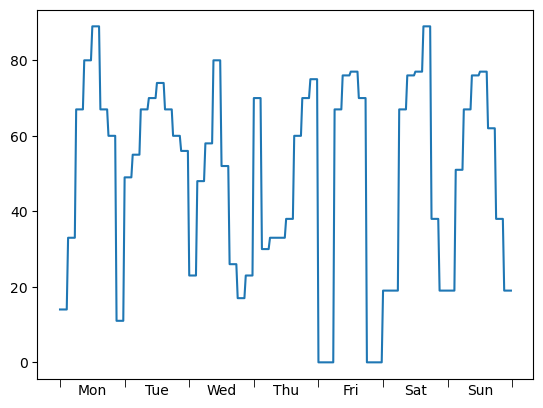

In [27]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

## A completely different approach: operation start and operation end time

An even simpler way of producing daily (and from them weekly) demand profiles is to specify the time of the day when the system operation starts and when it ends. This is done with the parameters `op_start` and `op_end`.

These parameters must be strings representing a time of the day in the format `"hh:mm"`. The "minutes" component of the time (i.e. the string `"mm"`) must be either `"00"` or `"30"`, since the maximum resolution for these profiles is 30 minutes. The "hours" component must have values from `"00"` to `"24"`. When midnight is the start of the operation time, it should be represented as `"00:00"`. When it is the end time, it should be represented as `"24:00"`.

When the daily profile is specified in this way, the rate of energy demand is assumed to be flat during the operation time of the thermal load.

If only the parameters `op_start` and `op_end` are provided, it is assumed that all days of the week have the same operation schedule.

In [28]:
# Defining the times at which operation starts and ends
op_start, op_end = "08:00", "18:00"

# Constructing the DemandProfile instance
demand_1 = DemandProfile(

    op_start = op_start,
    op_end = op_end,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

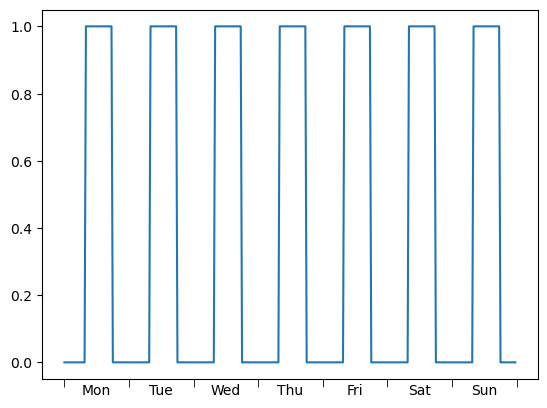

In [29]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

If all days of the week have the same schedule except for sunday which has no demand at all, this can be specified with the parameters `daily_demand_ratio_sunday` or `peak_demand_ratio_sunday`.

This is also valid if sunday, or saturday, have the same operation schedule but different demand levels.

In [30]:
# Defining the times at which operation starts and ends
op_start, op_end = "08:00", "18:00"

# Setting the demand on sunday to zero
daily_demand_ratio_sunday = 0

# Constructing the DemandProfile instance
demand_1 = DemandProfile(
    
    op_start = op_start,
    op_end = op_end,
    daily_demand_ratio_sunday = daily_demand_ratio_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

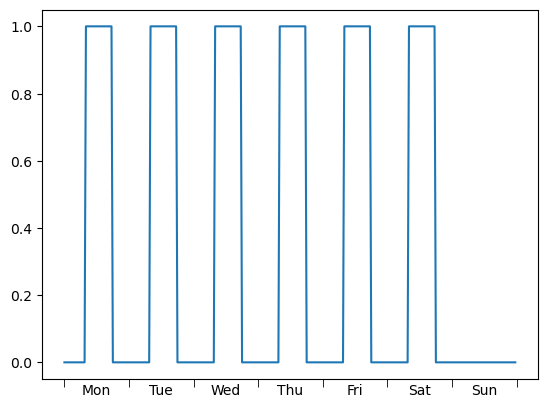

In [31]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

There is also the possibility of specifying special operation schedules for the weekend. This is done by specifying the parameters `op_start_saturday`, `op_end_saturday`, `op_start_sunday`, and `op_end_sunday`.

**The assumptions made are the same as before:**

- If a special schedule is set only for saturday, sunday is assumed to have no demand.
- If a special schedule is set only for sunday, saturday is assumed to be a normal day.

In [32]:
# Defining special schedules for saturday and sunday
op_start_saturday, op_end_saturday = "09:00", "16:00"
op_start_sunday, op_end_sunday = "10:00", "14:30"

# Constructing the DemandProfile instance
demand_1 = DemandProfile(
    
    op_start = op_start,
    op_end = op_end,
    op_start_saturday = op_start_saturday,
    op_end_saturday = op_end_saturday,
    op_start_sunday = op_start_sunday,
    op_end_sunday = op_end_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

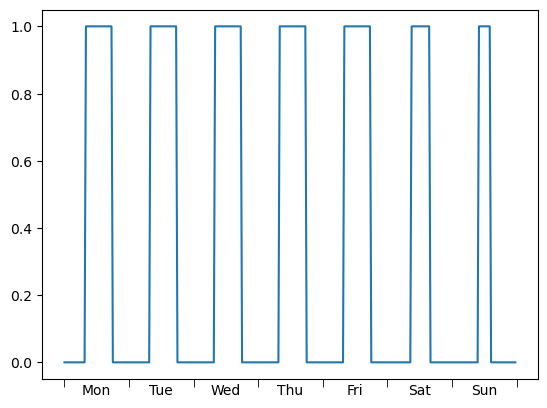

In [33]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

In [34]:
# Defining a special demand rates for saturday and sunday
# Notice that:
    # For saturday, the TOTAL daily demand ratio with respect to week days is set
    # For sunday, the PEAK demand ratio with respect to week days is set

daily_demand_ratio_saturday = 0.6
peak_demand_ratio_sunday = 0.2

# Constructing the DemandProfile instance
demand_1 = DemandProfile(
    
    op_start = op_start,
    op_end = op_end,
    op_start_saturday = op_start_saturday,
    op_end_saturday = op_end_saturday,
    op_start_sunday = op_start_sunday,
    op_end_sunday = op_end_sunday,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    peak_demand_ratio_sunday = peak_demand_ratio_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

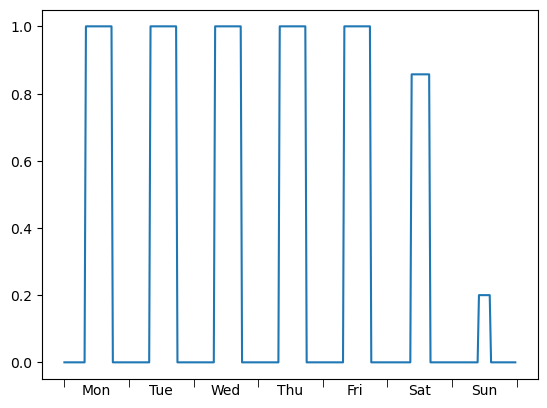

In [35]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

**An important thing to have in mind is the following:**

This approach is an alternative to the method of manually defining daily demand profiles (with parameters such as `daily_demand_profile`, `daily_demand_profile_saturday`, `daily_demand_profile_sunday`, `daily_demand_profiles`, and `weekly_demand_profile`), **and both approaches cannot be combined.** If, for instance, a `daily_demand_profile` is specified along with `op_start` and `op_end`, the two latter parameters will be ignored at the expense of the former. This is because a daily demand profile is preferable since it provides more information on how the energy demand is distributed throughout the day.

On the other hand, this approach ***can*** be combined with the parameters previously presented that can be used to manage the total daily demand or peak demand (`daily_demand_ratio_saturday`, `daily_demand_ratio_sunday`, `peak_demand_ratio_saturday`, `peak_demand_ratio_sunday`, `weekly_demand_factors`). However, this parameters are not required; if none of them is provided, the demand rate (or peak demand) is assumed to be the same for all days.

## Obtaining data from `DemandProfile` instances

`DemandProfile` instances are meant to store the demand data for a whole operation year of the heating system. The data they store is:

- Flowrate
- Temperature of the flow entering the heating system
- Setpoint of the system
- Demanded power

The demand conditions can be obtained using the `get_demand_conditions()` method of the class. When the conditions for a single instant in time are asked for, this method returns a dictionary with the following components:

- `"flowrate"`
- `"demanded_power"`
- `"T_in"`
- `"T_set"`

The variables inside this dictionary are numeric values corresponding to that instant.

The instant provided as input should be either a `datetime.datetime` object, a `pandas.Timestamp` object, or a `dictionary` with the components `"month"`, `"day"`, `"hour"`, and `"minute"`. It is also possible to skip this positional argument and provide the components just mentioned as keyword arguments to the method `get_demand_conditions`.

In [36]:
# Setting the instant as a datetime.datetime object
instant_1 = datetime( year = 2026, month = 5, day = 14, hour = 15, minute = 47 )

# Asking for the conditions with the method get_demand_conditions()
print( demand_1.get_demand_conditions( instant_1 ) )

{'flowrate': 7.722480788132648, 'demanded_power': 646217.19235094, 'T_in': 40.0, 'T_set': 60.0}


By default, the units of the returned quantities are in the SI system, except for temperature which is returned in C. The flowrate is returned by default as mass flowrate (in kg/s).

The units can be customized with the keyword arguments `flowrate_units`, `power_units`, and `temp_units` (or equivalently, `T_units`).

The flowrate can be automatically switched to volumetric flowrate simply by specifying units that correspond to that type of flowrate.

In [37]:
# Setting custom units for the demand conditions 
power_units = "kW"
flowrate_units = "m3/h"
temp_units = "F"

# Asking for the conditions with the method get_demand_conditions()
print( demand_1.get_demand_conditions( instant_1, power_units = power_units, flowrate_units = flowrate_units, temp_units = temp_units )  )

{'flowrate': 27.800930837277534, 'demanded_power': 646.21719235094, 'T_in': 104.0, 'T_set': 140.0}


Instead of defining a `datetime.datetime` instance or a `pandas.Tiemstamp` instance and providing it to the `get_demand_conditions` method, there are two alternative ways of obtaining the same behavior:

1. Passing the keyword arguments `month`, `day`, `hour`, and `minute` directly to the method.
2. Defining a dictionary which has the same keys as strings and passing it to the method instead of the `datetime.datetime`object.

In [38]:
# Obtaining the same results without passing the "instant_1" object to the method
# Keyword arguments are used instead

print( demand_1.get_demand_conditions( month = 5, day = 14, hour = 15, minute = 47 )  )

{'flowrate': 7.722480788132648, 'demanded_power': 646217.19235094, 'T_in': 40.0, 'T_set': 60.0}


In [39]:
# Obtaining the same results replacing the "instant_1" object with a dictionary

instant_1_dict = {
    "month": 5,
    "day": 14,
    "hour": 15,
    "minute": 47
}

print( demand_1.get_demand_conditions( instant_1_dict )  )

{'flowrate': 7.722480788132648, 'demanded_power': 646217.19235094, 'T_in': 40.0, 'T_set': 60.0}


### Obtaining the demand conditions throughout a period of time instead of a single instant

When the demand conditions are generated for a period between two instants instead of a single instant, the object returned is not a dictionary anymore, but a `pandas.DataFrame`. The first column of the `pandas.DataFrame` returned is called `"timestamp"`, and it contains all the instants considered for the data generation. The other columns have the same names as the components of the dictionary that gets returned for single instants.

Getting the demand conditions for time periods can be done in two ways:

1. By passing two time instants as positional arguments to the method `get_demand_conditions`.  
2. By passing a single `pandas.Datetimeindex` object as positional argument to the method.  

The first method just mentioned internally generates a `pandas.Datetimeindex` from the two positional arguments specified. By default, the `pandas.Datetimeindex` is created with the following configuration:

- `freq="min"`
- `inclusive="both"`
- `tz=None`

This configuration can be modified by passing the aforementioned arguments as keyword arguments to the `get_demand_conditions` method.

In [40]:
# Defining a pandas.Datetimeindex instance
dt1 = datetime( year = 2025, month = 3, day = 14, hour = 15, minute = 25 )
dt2 = datetime( year = 2025, month = 6, day = 23, hour = 10, minute = 48 )
datetimes = pd.date_range( dt1, dt2, freq = "min", inclusive = "both" )

# Obtaining the data from the DemandProfile instance using the pandas.Datetimeindex instance
print( demand_1.get_demand_conditions( datetimes ) )

                 timestamp   flowrate  demanded_power  T_in  T_set
0      2025-03-14 15:25:00   4.996795   418131.825800  40.0   60.0
1      2025-03-14 15:26:00   4.996795   418131.825800  40.0   60.0
2      2025-03-14 15:27:00   4.996795   418131.825800  40.0   60.0
3      2025-03-14 15:28:00   4.996795   418131.825800  40.0   60.0
4      2025-03-14 15:29:00   4.996795   418131.825800  40.0   60.0
...                    ...        ...             ...   ...    ...
145159 2025-06-23 10:44:00  10.007085   837392.843651  40.0   60.0
145160 2025-06-23 10:45:00  10.007085   837392.843651  40.0   60.0
145161 2025-06-23 10:46:00  10.007085   837392.843651  40.0   60.0
145162 2025-06-23 10:47:00  10.007085   837392.843651  40.0   60.0
145163 2025-06-23 10:48:00  10.007085   837392.843651  40.0   60.0

[145164 rows x 5 columns]


In [41]:
# Getting the same behavior by providing the two timestamps as positional arguments to the method 'get_demand_conditions'

print( demand_1.get_demand_conditions( dt1, dt2 ) )

                 timestamp   flowrate  demanded_power  T_in  T_set
0      2025-03-14 15:25:00   4.996795   418131.825800  40.0   60.0
1      2025-03-14 15:26:00   4.996795   418131.825800  40.0   60.0
2      2025-03-14 15:27:00   4.996795   418131.825800  40.0   60.0
3      2025-03-14 15:28:00   4.996795   418131.825800  40.0   60.0
4      2025-03-14 15:29:00   4.996795   418131.825800  40.0   60.0
...                    ...        ...             ...   ...    ...
145159 2025-06-23 10:44:00  10.007085   837392.843651  40.0   60.0
145160 2025-06-23 10:45:00  10.007085   837392.843651  40.0   60.0
145161 2025-06-23 10:46:00  10.007085   837392.843651  40.0   60.0
145162 2025-06-23 10:47:00  10.007085   837392.843651  40.0   60.0
145163 2025-06-23 10:48:00  10.007085   837392.843651  40.0   60.0

[145164 rows x 5 columns]
